In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:19<00:00, 118MB/s]



In [ ]:
from zipfile import ZipFile

with ZipFile("leapgestrecog.zip", 'r') as zip:
    zip.extractall()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
gesture_map = {
    '01_palm': 0,
    '02_l': 1,
    '03_fist': 2,
    '04_fist_moved': 3,
    '05_thumb': 4,
    '06_index': 5,
    '07_ok': 6,
    '08_palm_moved': 7,
    '09_c': 8,
    '10_down': 9
}

print("Gesture Labels Created")

Gesture Labels Created


In [ ]:
data = []
labels = []

path = "/content/leapGestRecog"

for subject in os.listdir(path):

    subject_path = os.path.join(path, subject)

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(subject_path, gesture)

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (64, 64))

            data.append(img)

            labels.append(gesture_map[gesture])

print("Images Loaded Successfully")
print("Total Images:", len(data))

Images Loaded Successfully
Total Images: 20000


In [ ]:
X = np.array(data)
y = np.array(labels)

# Normalize images
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 64, 64, 1)

# Convert labels to categorical
y = to_categorical(y)

print("Data Prepared Successfully")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

Data Prepared Successfully
X Shape: (20000, 64, 64, 1)
y Shape: (20000, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16000, 64, 64, 1)
Testing Data Shape: (4000, 64, 64, 1)


In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

print("CNN Model Built Successfully")

CNN Model Built Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")


Model Compiled Successfully


Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:18<00:00, 124MB/s]

Dataset Downloaded and Extracted Successfully
Images Loaded Successfully
Total Images: 20000
Data Prepared Successfully
X Shape: (20000, 64, 64, 1)
y Shape: (20000, 10)
Training Data Shape: (16000, 64, 64, 1)
Testing Data Shape: (4000, 64, 64, 1)
CNN Model Built Successfully
Model Compiled Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 191ms/step - accuracy: 0.8644 - loss: 0.4134 - val_accuracy: 0.9985 - val_loss: 0.0103
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 199ms/step - accuracy: 0.9852 - loss: 0.0458 - val_accuracy: 0.9995 - val_loss: 0.0038
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 93s 185ms/step - accuracy: 0.9897 - loss: 0.0341 - val_accuracy: 0.9992 - val_loss: 0.0037
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 184ms/step - accuracy: 0.9932 - loss: 0.0219 - val_accuracy: 0.9990 - val_loss: 0.0042
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9987 - val_loss: 0.0033
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 105s 210ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9992 - val_loss: 0.0013
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 185ms/step - accuracy: 0.9933 - loss: 0.0184 - val_accuracy: 0.9985 - val_loss: 0.0045
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 185ms/step - accuracy: 0.9937 - loss

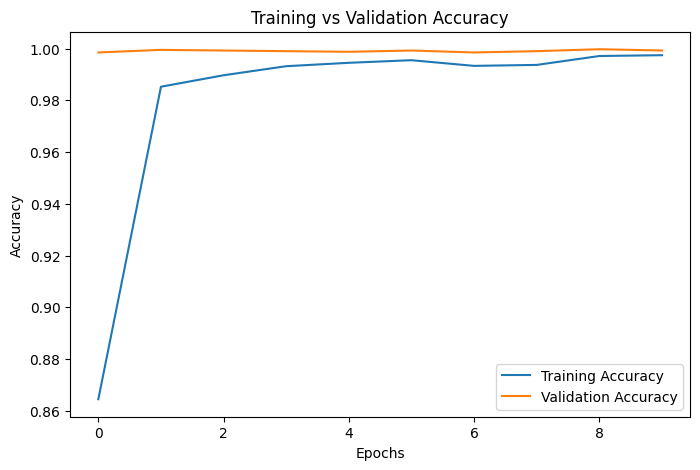

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2
import os
from zipfile import ZipFile

# --- Start Dataset Download and Extraction ---
# Ensure kaggle.json is configured correctly for this to work
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d gti-upm/leapgestrecog

# Extract the dataset
with ZipFile("leapgestrecog.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Downloaded and Extracted Successfully")
# --- End Dataset Download and Extraction ---

# --- Start Data Loading and Preprocessing ---

# Define gesture_map
gesture_map = {
    '01_palm': 0,
    '02_l': 1,
    '03_fist': 2,
    '04_fist_moved': 3,
    '05_thumb': 4,
    '06_index': 5,
    '07_ok': 6,
    '08_palm_moved': 7,
    '09_c': 8,
    '10_down': 9
}

data = []
labels = []

path = "/content/leapGestRecog"

for subject in os.listdir(path):

    subject_path = os.path.join(path, subject)

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(subject_path, gesture)

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (64, 64))

            data.append(img)

            labels.append(gesture_map[gesture])

print("Images Loaded Successfully")
print("Total Images:", len(data))

X = np.array(data)
y = np.array(labels)

# Normalize images
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 64, 64, 1)

# Convert labels to categorical
y = to_categorical(y)

print("Data Prepared Successfully")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# --- End Data Loading and Preprocessing ---

# Model Definition
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

print("CNN Model Built Successfully")

# Model Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

# Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [6]:
import numpy as np

# Predict on test data
predictions = model.predict(X_test)

# Convert predictions
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Display first 5 predictions
for i in range(5):
    print("Predicted:", predicted_classes[i],
          " | Actual:", true_classes[i])

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step
Predicted: 1  | Actual: 1
Predicted: 6  | Actual: 6
Predicted: 1  | Actual: 1
Predicted: 2  | Actual: 2
Predicted: 8  | Actual: 8


In [10]:
model.save("hand_gesture_model.keras")

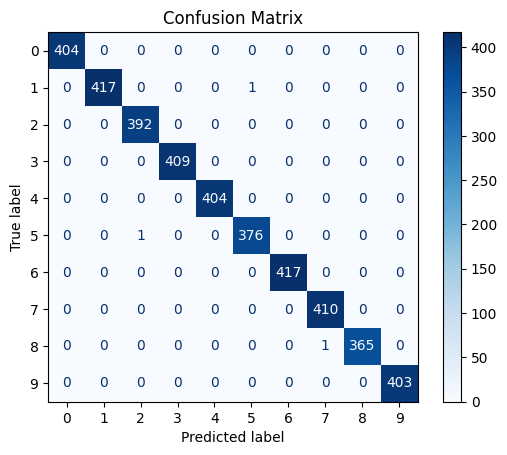

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()